In [3]:
import sys
import sys
sys.path.append(r"C:\Users\Rakesh\Documents\summer-project\src")

from two_level_mc import * # adjust if your notebook is nested differently
from functions_v2 import *

In [5]:
import shutil, os
pycache = r"C:\Users\Rakesh\Documents\summer-project\__pycache__"
if os.path.exists(pycache):
    shutil.rmtree(pycache)
    print("Deleted __pycache__")

In [7]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [9]:
edges, n_vertices, weights = load_graph(r"../../data/raw/power-US-Grid.mtx")
print(f"n_vertices={n_vertices}, edges={len(edges)}")

✓ Loaded: ../../data/raw/power-US-Grid.mtx
  Vertices : 4941
  Edges    : 6594
  Weighted : no

n_vertices=4941, edges=6594


In [11]:
check_connectivity(edges, n_vertices)

Components: 1
  -> Graph is fully connected, safe to proceed



1

In [13]:
# 3. Phase 1
A, D, L = build_graph_matrices(edges, n_vertices)

# 4. Phase 2 — sparse from the start, given graph size
lambda_min = compute_lambda_min(L, D)
L_sigma = build_shifted_laplacian(L, D, lambda_min)
print("L_sigma type:", type(L_sigma))

✓ Phase 1 complete: A, D, L built as sparse matrices
  Matrix size : 4941 x 4941
  Degree range: [1, 19]
  Non-zeros in L: 18129

✓ lambda_min = 0.000271
  (eigenvalues found: [0.         0.00027102])
✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)
  L_sigma type: sparse

L_sigma type: <class 'scipy.sparse._csc.csc_matrix'>


In [14]:
G_nx = nx.Graph()
G_nx.add_edges_from(edges)

In [15]:
gamma_in, gamma_out, diameter = find_diameter_endpoints(G_nx, n_sample=5, k_hop=4)

In [ ]:
gamma_in, gamma_out, diameter

In [19]:
check_boundary_fraction(gamma_in, gamma_out, n_vertices)

gamma_in: 23, gamma_out: 14, n_vertices: 4941
Boundary fraction: 0.7488%
  -> Likely safe for aggregation (comparable to validated successes).


0.00748836267961951

In [21]:
aggregate_of, n_coarse = build_capped_aggregation(G_nx, gamma_in, gamma_out, max_size=10)

In [23]:
summary = summarize_aggregation(aggregate_of, n_coarse, gamma_in, gamma_out)

n_coarse: 2074 (2074 aggregates)
Size distribution -- min: 2, max: 10, mean: 2.38
Singletons: 0 (0.0%)
gamma_in_coarse: 15, gamma_out_coarse: 7
Overlap (must be empty): set()
Interior coarse vertices: 2052 (98.9%)


In [25]:
setup = TwoLevelSetup.build(
    edges, n_vertices, L_sigma, lambda_min,
    gamma_in, gamma_out,
    build_incidence_matrix, sparse_cholesky,
    max_size=10
)

gamma_in: 23, gamma_out: 14, n_vertices: 4941
Boundary fraction: 0.7488%
  -> Likely safe for aggregation (comparable to validated successes).
n_coarse: 2074 (2074 aggregates)
Size distribution -- min: 2, max: 10, mean: 2.38
Singletons: 0 (0.0%)
gamma_in_coarse: 15, gamma_out_coarse: 7
Overlap (must be empty): set()
Interior coarse vertices: 2052 (98.9%)
coarse edges: 3282 (from 6594 fine edges)


In [33]:
result = run_paired_validation(setup, N=100)

N = 100 paired samples
Q_fine   : mean=0.152150  var=0.000002
Q_coarse : mean=0.236165  var=0.000005
Q_fine - Q_coarse : mean=-0.084015  var=0.000001
Correlation(Q_fine, Q_coarse): 0.9981
Variance reduction: 3.44x


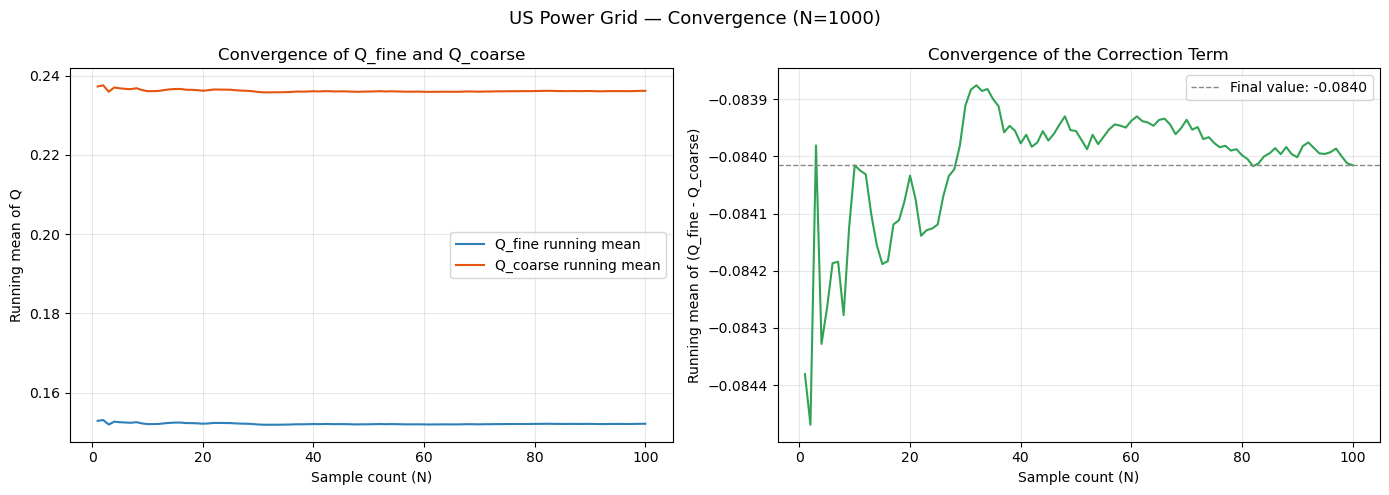

In [35]:
plot_convergence(result, title="US Power Grid — Convergence (N=1000)")

In [39]:
estimate = two_level_estimate(setup, result, N_coarse_only=200)

Coarse-only base estimate (N=200): 0.236017
Correction term mean (paired samples): -0.084015
Two-level estimate of E[Q_fine]: 0.152001
Direct fine-only mean (for comparison): 0.152150
